# Calculate wind speed/wind stress magnitude from submonthly vector data, for specified time/space domain 
## calculate statistitcal moments (mean, std, max) for each month


data source etc

In [1]:
#src = 'JRA55-do-1.4'
#vNam = ['uas','vas'] ;
#diri = '/g/data/ik11/inputs/JRA-55/MRI-JRA55-do/MRI-JRA55-do-1-4-0/atmos/'

ovNam = 'windspeed'

src = 'ERA5'
diri = '/g/data/rt52/era5/single-levels/reanalysis/' 
vNam = ['u10','v10'] ; 
#unfortunately on gdata they switched the variable on the filenammes from u10 to 10u
#so a cludgey extra file-variable-name is required. Because otherwise it would be easy and logical
fvNam = ['10u','10v'] 


#monthly winstress
dirtau = '/g/data/gv90/wrh581/ERA5/'
filtau = dirtau+'ERA5_tau_monthly_SH_1979-2025.nc'
tauNam = ['avg_iews','avg_inss']



#Sea ice data
dirice = '/g/data/gv90/wrh581/NSIDC/monthly_sic/'
filice = [dirice+'sic_pss25_197811-202512_v06r00.nc']#,
       # diri+'sic_pss25_202601_F17_icdr_v04r00.nc',
       # diri+'sic_pss25_202602_F17_icdr_v04r00.nc',
       # diri+'ic_pss25_202603_F17_icdr_v04r00.nc',
       # diri+'sic_pss25_202604_F17_icdr_v04r00.nc']
iceNam = 'cdr_seaice_conc_monthly'


#time and space domain
clst = 2000 ; clen = 2025 
anom_year = 2023
month = [5,6,7]
latmin = -90. ; latmax = -50. 


#output file
diro = '/g/data/jk72/wrh581/'
filo = src+'_'+ovNam+'_stats_'+str(anom_year)+'.png'

In [2]:
#imports
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import numpy as np
import xarray as xr
import cf_xarray as cf
import pandas as pd
import cartopy.crs as crs
import cartopy as ccrs
import subprocess


import dask
from dask.distributed import Client
Client=Client()

Read hourly wind components 
reduce to timescale of interest

In [3]:
#clunky piece of code to get a concatenated list of years 
#usefule when searching for a subset of files
yrst = np.min([clst, anom_year]) ; yren = np.max([clst, clen])
if yrst == yren:
    yrstr = str(yrst)
else:
    yrstr = [str(int) for int in  np.arange(yrst, 1+yren) ] 
    yrstr ='{'+','.join(yrstr)+'}'

    
#function to read data and reduce time


def read_wind(fvar, var):
    if src == 'ERA5':
        CMD = 'ls '+diri+fvar+'/'+yrstr+'/'+fvar+'_era5_oper_sfc_*.nc' 
    else:
        CMD = 'ls '+diri+fvar+'/'+fvar+'_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-4-0_gr_'+yrstr+'*.nc'
        
    fili = subprocess.run(CMD, shell=True, capture_output=True)  #run CMD as a bash command
    fili = fili.stdout.decode().split('\n')[0:-1] 

    data = xr.open_mfdataset(fili, 
                             combine="by_coords",
                             parallel = True, 
                             chunks = {'time' : 744}
                        )    
    
    #spatial coords may be names 'lat,lon' or <latitude,longitude>
    out  = data[var].cf.sel(latitude = slice(latmax,latmin))
    out  = out.isel(time = out.time.dt.month.isin(month))

    return out


U = [read_wind(fvNam[0],vNam[0]),
     read_wind(fvNam[1],vNam[1])]


chunks = {U[0].cf['time'].name : 31 * 24,
          U[0].cf['latitude'].name : -1,
          U[0].cf['longitude'].name : 360}

for i in [0,1]:
    U[i] = U[i].chunk(chunks)

### Calc wind speed

In [4]:
#stay 

speed = xr.apply_ufunc(
    np.hypot,
    U[0],
    U[1],
    dask='parallelized',
    output_dtypes=[np.float32]
)

#  enforce float32 to halve memory
speed = speed.astype('float32')


Get stats for each calendar month

In [5]:
speed

<xarray.DataArray 'u10' (time: 57408, latitude: 161, longitude: 1440)> Size: 53GB
dask.array<transpose, shape=(57408, 161, 1440), dtype=float32, chunksize=(744, 161, 360), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 459kB 2000-05-01 ... 2025-07-31T23:00:00
  * latitude   (latitude) float32 644B -50.0 -50.25 -50.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
Attributes:
    units:      m s**-1
    long_name:  10 metre U wind component

In [6]:

#resample only once
resampled = speed.resample(time= '1ME')
    
#cpmute BEFORE merging into a sigle dataset, so that the compute tasks are serialized/not all heppening at once
monmean = resampled.mean(('time')).compute()
monmax = resampled.max(('time')).compute()
monsd  = resampled.std(('time')).compute()


#create a dataset
vars_ = ['mean', 'max', 'sd']
stats = xr.Dataset({vars_[0] : monmean ,
                    vars_[1] : monmax,
                    vars_[2] : monsd})



/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 23.35 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 23.35 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/cli

In [7]:
clim = stats.sel(time = slice(str(clst),str(clen)))
anom = stats.sel(time = str(anom_year))

clim = clim.mean('time').compute()
anom = anom.mean('time').compute()


In [8]:
anom = (anom - clim).compute()
clim_std = stats.sel(time = slice(str(clst),str(clen))).std('time')
anom_norm = (anom/clim_std).compute()

### monthly-mean wind stress curl

In [9]:
#read tau
tau = xr.open_dataset(filtau, chunks ={'time' : 120 } )
tau  = tau.cf.sel(latitude =  slice(latmax,latmin))

tNam = tau.cf['time'].name 
month_mask = np.isin(tau[tNam].dt.month, month)
tau  = tau.sel(**{tNam : month_mask})
tau = tau.groupby(tau[tNam].dt.year).mean(tNam)



In [10]:
#curl
Re = 6371000  # Earth radius (m)

# convert degrees → radians once
xNam = tau.cf['longitude'].name ; yNam = tau.cf['latitude'].name
lat_rad = np.deg2rad(tau[yNam])
lon_rad = np.deg2rad(tau[xNam])

# metric terms
coslat = np.cos(lat_rad)

# compute derivatives using xarray (keeps dask compatibility)
dtaudy_dlon = tau[tauNam[1]].differentiate(xNam) * (np.pi / 180)
dtaudx_dlat = tau[tauNam[0]].differentiate(yNam) * (np.pi / 180)

# apply spherical scaling
curl = (
    dtaudy_dlon / (Re * coslat)
    - dtaudx_dlat / Re
)

curl.name = "wind_stress_curl"


#calc normalise ad add to dataset
curlclim = curl.sel(year =  slice(clst, clen)).mean('year').compute()
curlsd  = curl.sel(year =  slice(clst, clen)).std('year').compute()
curl    = (curl.sel(year = anom_year) - curlclim)

anom      = anom.assign(curl = curl).compute()
anom_norm = anom_norm.assign(curl = curl/curlsd).compute()

vars_.append('curl')


### Sea ice data

In [11]:


try:
    icedata = xr.open_dataset(filice, chunks = -1).cf.sel(time=slice(str(yrst),str(yren))).drop_vars([iceNam+'_stdev',iceNam+'_qa_flag','crs'])
except:
     icedata = xr.open_mfdataset(filice, chunks = -1, parallel=True).cf.sel(time=slice(str(yrst),str(yren))).drop_vars([iceNam+'_stdev',iceNam+'_qa_flag','crs'])

#grid info
icedata.attrs['gridtype'] = crs.SouthPolarStereo()
icedata = xr.merge([icedata, xr.open_dataset(filice[0], 
                                             group = 'cdr_supplementary').drop_vars('surface_type_mask')])



#narrow down to last month in range
icedata = icedata.isel(time = icedata.time.dt.month == np.max(month))


iceclim = icedata.sel(time = slice(str(clst),str(clen))).mean('time')
icedata = icedata.sel(time = str( anom_year) ).squeeze()


iceclim = iceclim.compute()
icedata = icedata.compute()

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/xarray/backends/api.py:587: RuntimeWarning: 'swan' fails while guessing
  engine = plugins.guess_engine(filename_or_obj)


# Map plots

In [12]:
for v in vars_:
    print(anom_norm[v].max().values)

2.615844249725342
2.6778066158294678
2.6671857833862305
3.3219540108369108


### Map plot of anoms, with contour line where norm anoms > 2sigma

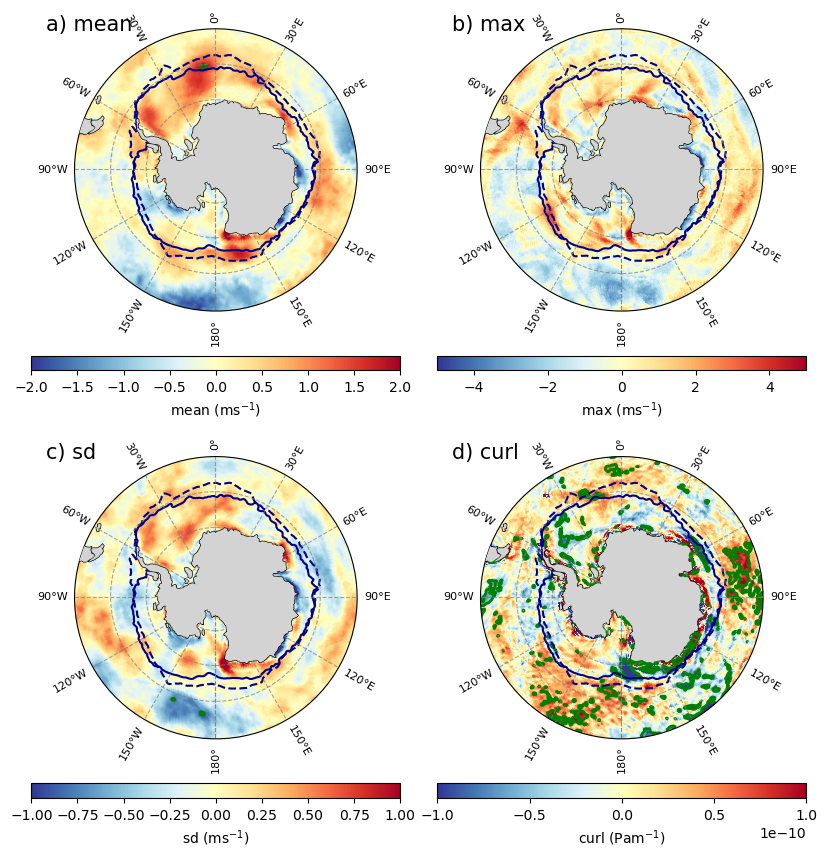

In [34]:

# PROJECTION
proj = crs.SouthPolarStereo() #crs.Miller():
data_crs = crs.PlateCarree()

# ======================
# COLOR map and label fonts
# ======================

TISIZ = 15  #panel labels
TMSIZ = 8 #tickmarks

cmap = 'RdYlBu_r'
cmax=[2.,5.,1.,1.e-10] 


# =================
# panel set up
# ====================

nrow = 2; ncol = 2
fig, axes = plt.subplots(nrow, ncol, 
                         figsize=(10, 10),
                         subplot_kw={'projection': proj})

axes = axes.ravel() #flatted 'axes' object so that looping is easier
plt.subplots_adjust(wspace=0.1, hspace=0.25)

# Panel labels
panel_labels = ['a) '+vars_[0], 'b) '+vars_[1], 
                'c) '+vars_[2], 'd) '+vars_[3]] 


# ======================
# PLOTTING LOOP
# ======================

def mapplot (panel_axes, plot_var,  maxlev):
    ax = panel_axes

    im = anom[plot_var].plot.pcolormesh(
        ax=ax,
        transform=data_crs,
        cmap=cmap,
        vmin=-maxlev,
        vmax= maxlev,
        add_colorbar=False,
        rasterized=True
    )


    anom_norm[plot_var].plot.contour(ax = ax,
                                     transform=data_crs, 
                                     colors='green', linestyles='solid', 
                                     levels=[-2.,2.], 
                                     linewidths=2.)
    
    #sea ice edge
    icecolor = 'darkblue' ; icethick = 1.5
    # climatology 
    iceclim[iceNam].plot.contour(ax=ax,transform=icedata.gridtype,
                               colors=icecolor, linestyles='dashed', 
                               levels=[0.15], linewidths =icethick)  

    # anomaly 
    icedata[iceNam].plot.contour(ax=ax, transform=icedata.gridtype, 
                               colors=icecolor, linestyles='solid', 
                               levels=[0.15], linewidths= icethick)  
        
    # grid and land
    ax.add_feature(ccrs.feature.LAND, facecolor='lightgray', zorder=5)  # color land using RGB coords
    ax.coastlines(resolution='110m', color='black', linewidth=1)
    gl = ax.gridlines(zorder=2, draw_labels = True,
                         xlocs=np.arange(-180, 181, 30),
                         ylocs=np.arange(-80, -49, 10),
                         linewidth=0.8, color='gray', alpha=0.7, linestyle='--')

    ax.set_extent([-180, 180, -90, latmax], data_crs)
    # Hide latitude labels completely
    gl.xlabel_style = {'size': TMSIZ} # Increase longitude tick font size
    gl.ylabel_style  = {'color': (0.,0.,0.,0.)}  #make longitue markers invisible
    ax.set_title('') 

    #set aspect ratio or boundary, appropriate to plot projection
    if proj == crs.Miller():
        ax.set_aspect(4)
    else:
        #make polar seterographic plot circular
        theta = np.linspace(0, 2*np.pi, 100)
        center, radius = [0.5, 0.5], 0.5
        verts = np.vstack([np.sin(theta), np.cos(theta)]).T
        circle = mpath.Path(verts * radius + center)
        ax.set_boundary(circle, transform=ax.transAxes)
    

for j, v in enumerate(vars_):
    mapplot(axes[j], v, cmax[j])



# ======================
# COLORBARS (horizontal)
# ======================

for j in range(len(vars_)):
    ax = axes[j]
    im = ax.collections[0]   # the pcolormesh

    cb = fig.colorbar(
        im,
        ax=ax,
        orientation='horizontal',
        pad=0.13,
        fraction=0.045,
        aspect = 25
    )

    if j <= 2:
        cb.set_label(vars_[j]+' (ms$^{-1}$)', fontsize = 10)
    else:
        cb.set_label(vars_[j]+' (Pam$^{-1}$)', fontsize = 10)  


# ======================
# PANEL LABELS
# ======================


for i in range(len(vars_)):
    axes[i].text(
        -0.1, 1.05,
        panel_labels[i],
        transform=axes[i].transAxes,
        ha='left', va='top',
        fontsize=TISIZ, fontweight='normal'
    )


plt.savefig(diro+filo)